In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('academIQ_burnout_dataset_v2.csv')
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loaded: (20661, 24)
Columns: ['student_id', 'all_clicks', 'active_days', 'access_frequency', 'material_clicks', 'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score', 'assignment_submissions', 'final_grade', 'total_time_spent', 'procrastination_index', 'late_submission_count', 'max_burnout_score', 'avg_burnout_score', 'spike_count', 'crash_count', 'decline_weeks', 'avg_instability', 'max_instability', 'burnout_weeks', 'total_weeks', 'burnout_week_ratio', 'burnout_risk']


In [3]:
def burnout_label(row):
    """
    A student is labelled burnout=1 if:
    (a) they were active enough that a pattern is even measurable, AND
    (b) they exhibit at least TWO distinct burnout signal types.

    Requiring multiple independent signals makes the label robust against
    noise in any single indicator.
    """

    if row['active_days'] < 5 or row['all_clicks'] < 50:
        return 0

    signals = 0
    # Signal 1: spike-and-crash engagement pattern
    if row['spike_count'] >= 2 and row['crash_count'] >= 1:
        signals += 1
    # Signal 2: sustained decline (4+ weeks of falling engagement)
    if row['decline_weeks'] >= 4:
        signals += 1
    # Signal 3: high week-to-week instability
    if row['max_instability'] >= 0.15:
        signals += 1
    # Signal 4: consistently elevated burnout-pattern score
    if row['avg_burnout_score'] >= 0.1:
        signals += 1
    # Signal 5: multiple flagged weeks
    if row['burnout_weeks'] >= 3:
        signals += 1

    return int(signals >= 2)


df['burnout_label'] = df.apply(burnout_label, axis=1)
n_pos = int(df['burnout_label'].sum())
print(f"\nRule-based positives: {n_pos} of {len(df)} ({n_pos/len(df)*100:.2f}%)")

print("\nMean final_grade by label (sanity check):")
print(df.groupby('burnout_label')['final_grade'].agg(['mean', 'count']))


Rule-based positives: 4625 of 20661 (22.39%)

Mean final_grade by label (sanity check):
                    mean  count
burnout_label                  
0              52.323210  16036
1              59.545946   4625


In [4]:
df['clicks_per_day'] = np.where(df['active_days']>0,
                                df['all_clicks']/df['active_days'], 0)
df['time_per_day']   = np.where(df['active_days']>0,
                                df['total_time_spent']/df['active_days'], 0)
df['time_per_click'] = np.where(df['all_clicks']>0,
                                df['total_time_spent']/df['all_clicks'], 0)
df['material_intensity'] = np.where(df['active_days']>0,
                                    df['material_clicks']/df['active_days'], 0)
df['quiz_rate'] = np.where(df['active_days']>0,
                           df['quiz_attempts']/df['active_days'], 0)
df['late_ratio'] = np.where(df['assignment_submissions']>0,
                            df['late_submission_count']/df['assignment_submissions'], 0)
df['quiz_performance'] = df['avg_quiz_score'] * np.log1p(df['quiz_attempts'])
df['assignment_performance'] = df['avg_assignment_score'] * np.log1p(df['assignment_submissions'])

# Log-transform skewed features
LOG_COLS = ['all_clicks', 'material_clicks', 'total_time_spent',
            'clicks_per_day', 'time_per_day', 'time_per_click',
            'material_intensity']
for col in LOG_COLS:
    df[col] = np.log1p(df[col])

# Winsorize procrastination_index
PROC_LOW, PROC_HIGH = df['procrastination_index'].quantile([0.01, 0.99])
df['procrastination_index'] = df['procrastination_index'].clip(PROC_LOW, PROC_HIGH)

FEATURE_COLS = [
    'all_clicks', 'active_days', 'access_frequency', 'material_clicks',
    'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
    'assignment_submissions', 'total_time_spent', 'procrastination_index',
    'late_submission_count',
    'clicks_per_day', 'time_per_day', 'time_per_click', 'material_intensity',
    'quiz_rate', 'late_ratio', 'quiz_performance', 'assignment_performance',
]
X = df[FEATURE_COLS].copy()
y = df['burnout_label'].values
print(f"\nFeatures: {len(FEATURE_COLS)}, positives: {y.sum()} ({y.mean()*100:.2f}%)")


Features: 19, positives: 4625 (22.39%)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)
print(f"\nTrain: {X_train_p.shape}, Test: {X_test_p.shape}")


Train: (16528, 19), Test: (4133, 19)


In [6]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train_p, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=-1, num_parallel_tree=None, ...)

In [7]:
# Threshold selection via precision-recall curve
y_prob = model.predict_proba(X_test_p)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.argmax(f1))
BEST_THRESHOLD = float(thresholds[best_idx])

print(f"\nBest F1 threshold: {BEST_THRESHOLD:.3f}")
print(f"  Precision: {precision[best_idx]:.3f}")
print(f"  Recall:    {recall[best_idx]:.3f}")
print(f"  F1:        {f1[best_idx]:.3f}")

# Optional - high-recall threshold for a wellness product
high_recall_mask = recall[:-1] >= 0.80
if high_recall_mask.any():
    idx = int(np.where(high_recall_mask)[0][-1])
    HR_THRESHOLD = float(thresholds[idx])
    print(f"\nHigh-recall (>=0.80) threshold: {HR_THRESHOLD:.3f}")
    print(f"  Precision at that threshold: {precision[idx]:.3f}")


Best F1 threshold: 0.558
  Precision: 0.909
  Recall:    0.929
  F1:        0.919

High-recall (>=0.80) threshold: 0.867
  Precision at that threshold: 0.959



 BURNOUT DETECTION - FINAL TEST METRICS
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.98      3208
     Burnout       0.91      0.93      0.92       925

    accuracy                           0.96      4133
   macro avg       0.94      0.95      0.95      4133
weighted avg       0.96      0.96      0.96      4133

AUC-ROC: 0.9899
AUC-PR:  0.9716   <-- main metric for imbalanced classes
          (random baseline AUC-PR = 0.2238, so this is 4.3x random)


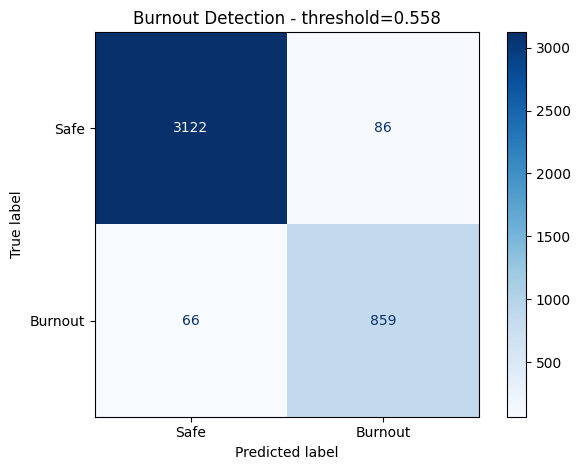

In [8]:
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)
print("\n" + "="*50)
print(" BURNOUT DETECTION - FINAL TEST METRICS")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Burnout']))
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR:  {auc_pr:.4f}   <-- main metric for imbalanced classes")
print(f"          (random baseline AUC-PR = {y_test.mean():.4f}, "
      f"so this is {auc_pr/y_test.mean():.1f}x random)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Safe', 'Burnout'], cmap='Blues',
)
plt.title(f'Burnout Detection - threshold={BEST_THRESHOLD:.3f}')
plt.tight_layout()
plt.savefig('burnout_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
cv_pipe = Pipeline([
    ('prep', Pipeline([('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler())])),
    ('clf', XGBClassifier(**model.get_params())),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_roc = cross_val_score(cv_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_pr  = cross_val_score(cv_pipe, X, y, cv=cv, scoring='average_precision',
                         n_jobs=-1)
print(f"\n5-fold CV AUC-ROC: {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}")
print(f"5-fold CV AUC-PR:  {cv_pr.mean():.4f} +/- {cv_pr.std():.4f}")


5-fold CV AUC-ROC: 0.9884 +/- 0.0020
5-fold CV AUC-PR:  0.9685 +/- 0.0042



Top 10 features by importance:
               feature  importance
        time_per_click    0.176056
      total_time_spent    0.115610
             quiz_rate    0.114605
         quiz_attempts    0.112239
            all_clicks    0.077496
      quiz_performance    0.056958
assignment_submissions    0.054274
 procrastination_index    0.038875
           active_days    0.037444
            late_ratio    0.029179


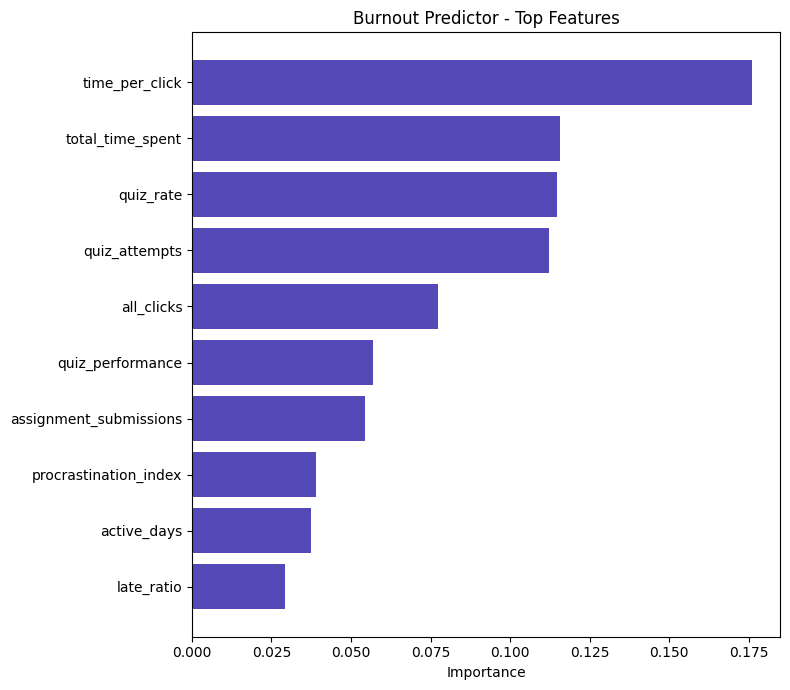

In [10]:
imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)
print("\nTop 10 features by importance:")
print(imp.head(10).to_string(index=False))

plt.figure(figsize=(8, 7))
top10 = imp.head(10)
plt.barh(top10['feature'][::-1], top10['importance'][::-1], color='#534AB7')
plt.xlabel('Importance')
plt.title('Burnout Predictor - Top Features')
plt.tight_layout()
plt.savefig('burnout_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
def get_risk_level(prob, threshold=BEST_THRESHOLD):
    """Bands anchored to the decision threshold for internal consistency."""
    if prob < threshold * 0.6:
        return 'Safe'
    elif prob < threshold:
        return 'Low Risk'        # under threshold but worth watching
    elif prob < min(threshold + 0.2, 0.95):
        return 'Medium Risk'
    else:
        return 'High Risk'


# Apply to the whole dataset for downstream use
X_all_p = preprocessor.transform(X)
df['burnout_probability'] = model.predict_proba(X_all_p)[:, 1]
df['burnout_predicted'] = (df['burnout_probability'] >= BEST_THRESHOLD).astype(int)
df['risk_level'] = df['burnout_probability'].apply(get_risk_level)

# Consistency check
assert (df.loc[df['risk_level'].isin(['Medium Risk','High Risk']),
               'burnout_predicted'] == 1).all()
assert (df.loc[df['risk_level'] == 'Safe',
               'burnout_predicted'] == 0).all()
print("\nConsistency check (risk_level vs burnout_predicted): PASSED")
print(f"\nRisk level distribution:\n{df['risk_level'].value_counts()}")



Consistency check (risk_level vs burnout_predicted): PASSED

Risk level distribution:
risk_level
Safe           15609
High Risk       4535
Low Risk         291
Medium Risk      226
Name: count, dtype: int64


In [12]:
print(df['burnout_label'].value_counts())

burnout_label
0    16036
1     4625
Name: count, dtype: int64


In [13]:
print(f"y_train positives: {y_train.sum()}")
print(f"y_test positives:  {y_test.sum()}")

y_train positives: 3700
y_test positives:  925


In [14]:
print("Label distribution in full dataset:")
print(df['burnout_label'].value_counts())
print(f"\nTotal positives: {df['burnout_label'].sum()}")

Label distribution in full dataset:
burnout_label
0    16036
1     4625
Name: count, dtype: int64

Total positives: 4625


In [ ]:

# SAVE MODEL ARTIFACTS  (run after training + threshold cells)
import joblib

burnout_artifacts = {
    'model':        model,            # trained XGBClassifier
    'preprocessor': preprocessor,     # SimpleImputer(median) + StandardScaler
    'feature_cols': FEATURE_COLS,     # exact feature columns + order
    'threshold':    BEST_THRESHOLD,   # prob >= threshold  ->  burnout = 1
    'log_cols':     LOG_COLS,         # features that were log1p-transformed
    'proc_clip':    (float(PROC_LOW), float(PROC_HIGH)),  # winsorize bounds
}
joblib.dump(burnout_artifacts, 'burnout_model.pkl')
print('Saved burnout_model.pkl ->', list(burnout_artifacts.keys()))

# Single file = one reliable download in Colab
try:
    from google.colab import files
    files.download('burnout_model.pkl')
except Exception as e:
    print('Not in Colab (download skipped):', e)
